# Load-Shedding Machine Learning Prediction System
### Capstone Pipeline — End-to-End Execution

This notebook builds an end-to-end pipeline that predicts South African load-shedding risk from historical Eskom system data and weather observations. It follows the CRISP-DM stages: data loading, feature engineering, model training and comparison, evaluation, and deployment artifact generation.

**Note:** outputs shown are from the author's last full run. Cells are ordered to run correctly top-to-bottom (`Run All`) in a fresh kernel.

**Models compared:** Random Forest, XGBoost, HistGradientBoosting (multiclass stage prediction), a binary HistGradientBoosting deployment model, and an LSTM neural network for comparison.

**A note on data leakage:** an earlier version of this pipeline included `stage_lag1/2/24` (the load-shedding stage from 1, 2, and 24 hours prior) as model features. Because load-shedding stages persist for blocks of hours, this let the model effectively see a near-answer rather than learn from demand and weather patterns, producing an inflated accuracy of 98.8%. These lag-of-target features have been identified and excluded (see Phase 2 below); the corrected, honest performance is reported in Phase 3.

## Phase 0 — Setup

In [1]:
import json
import sqlite3
import warnings
import time as time_module
import xgboost as xgb
from pathlib import Path
from typing import Dict, Iterable, List, Tuple
import plotly.graph_objects as go

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Paths – update these if needed
ESKOM_PATH = "ESK2033.csv"
SEPUSH_PATH = "EskomSePush_history.csv"
OUTPUT_DIR = Path("capstone_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Normalisation helpers
def normalise_column_name(column_name: str) -> str:
    text = str(column_name).strip().lower()
    replacements = {
        "date time hour beginning": "datetime",
        "date_time_hour_beginning": "datetime",
        "created_at": "datetime",
        "date": "datetime",
        " ": "_",
        "-": "_",
        "/": "_",
        "+": "_plus_",
        "(": "",
        ")": "",
        "%": "percent",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_")

def normalise_columns(df):
    df = df.copy()
    df.columns = [normalise_column_name(col) for col in df.columns]
    return df

def make_datetime_naive(values):
    dt = pd.to_datetime(values, errors="coerce")
    if getattr(dt.dt, "tz", None) is not None:
        dt = dt.dt.tz_localize(None)
    return dt

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def require_columns(df, required):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

def convert_numeric_columns(df, exclude=()):
    df = df.copy()
    exclude = set(exclude)
    for col in df.columns:
        if col not in exclude:
            df[col] = pd.to_numeric(df[col], errors="ignore")
    return df

def print_section(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)

## Phase 1 — Data Loading
Loads the raw Eskom system-status export and the EskomSePush stage-history export, normalises column names, and merges them into a single hourly master dataset.

In [3]:
print_section("PHASE 1 – LOADING ESKOM DATA")

ESKOM_PATH = r"C:\Users\Student\Desktop\Capstone\ESK2033.csv"
SEPUSH_PATH = r"C:\Users\Student\Desktop\Capstone\EskomSePush_history.csv"

print_section("PHASE 1 – LOADING ESKOM DATA")

# Read Eskom CSV
eskom_df = pd.read_csv(ESKOM_PATH)
eskom_df = normalise_columns(eskom_df)

# Remove any existing datetime column (we'll generate our own)
datetime_col = None
for col in eskom_df.columns:
    if 'datetime' in col or 'time' in col or 'date' in col:
        datetime_col = col
        break
if datetime_col is not None:
    eskom_df = eskom_df.drop(columns=[datetime_col], errors="ignore")

# Generate a reliable hourly datetime index
eskom_df["datetime"] = pd.date_range(
    start="2018-04-01 00:00:00",
    periods=len(eskom_df),
    freq="h"
)
eskom_df = eskom_df.drop_duplicates().sort_values("datetime").dropna(subset=["datetime"])
eskom_df = convert_numeric_columns(eskom_df, exclude=["datetime"])
print(f"Eskom shape: {eskom_df.shape}")  # Expected: (43824, 42)

print_section("PHASE 1 – DOWNLOADING WEATHER DATA")
start_date = eskom_df["datetime"].min().strftime("%Y-%m-%d")
end_date = eskom_df["datetime"].max().strftime("%Y-%m-%d")
print(f"Weather range: {start_date} to {end_date}")  # 2018-04-01 to 2023-03-31

# ----- Weather caching -----
CACHE_WEATHER_PATH = OUTPUT_DIR / "weather_cache.csv"

def get_weather_data(start_date, end_date):
    """Return weather DataFrame, using cached file if available and matching date range."""
    if CACHE_WEATHER_PATH.exists():
        cached = pd.read_csv(CACHE_WEATHER_PATH)
        cached["datetime"] = make_datetime_naive(cached["datetime"])
        if cached["datetime"].min().strftime("%Y-%m-%d") == start_date and \
           cached["datetime"].max().strftime("%Y-%m-%d") == end_date:
            print("Using cached weather data.")
            return cached
    print("Downloading weather data from Open-Meteo...")
    weather_url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": -28.7435,
        "longitude": 24.7626,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join([
            "temperature_2m", "apparent_temperature", "wind_speed_10m",
            "wind_speed_100m", "shortwave_radiation", "cloud_cover",
            "precipitation", "surface_pressure", "dew_point_2m"
        ]),
        "timezone": "Africa/Johannesburg"
    }
    resp = requests.get(weather_url, params=params, timeout=120)
    resp.raise_for_status()
    weather_json = resp.json()
    weather_df = pd.DataFrame(weather_json["hourly"])
    weather_df = normalise_columns(weather_df)
    weather_df.rename(columns={"time": "datetime"}, inplace=True)
    weather_df["datetime"] = make_datetime_naive(weather_df["datetime"])
    weather_df = weather_df.drop_duplicates().sort_values("datetime")
    weather_df = convert_numeric_columns(weather_df, exclude=["datetime"])
    weather_df.to_csv(CACHE_WEATHER_PATH, index=False)
    print("Weather data cached.")
    return weather_df

weather_df = get_weather_data(start_date, end_date)
print(f"Weather shape: {weather_df.shape}")  # Expected: (43824, 10)

print_section("PHASE 1 – LOADING SEPUSH DATA")
sep_df = pd.read_csv(SEPUSH_PATH)
sep_df = normalise_columns(sep_df)
print("Sepush columns:", sep_df.columns.tolist())

# Find datetime column flexibly
datetime_col = None
for col in sep_df.columns:
    if 'datetime' in col or 'time' in col or 'created' in col or 'date' in col:
        datetime_col = col
        break

if datetime_col is None:
    raise ValueError(f"Sepush: no datetime column found. Columns: {sep_df.columns.tolist()}")

sep_df["datetime"] = make_datetime_naive(sep_df[datetime_col])
sep_df = sep_df.drop(columns=[datetime_col], errors="ignore")
sep_df = sep_df.dropna(subset=["datetime"]).drop_duplicates()
sep_df = sep_df.sort_values("datetime").set_index("datetime")
sep_df = convert_numeric_columns(sep_df)
sep_hourly = sep_df.resample("h").ffill().reset_index()
print(f"Sepush hourly shape: {sep_hourly.shape}")  # Expected: (66058, 2)

print_section("PHASE 1 – MERGING")
master_df = eskom_df.merge(weather_df, on="datetime", how="left")
master_df = master_df.merge(sep_hourly, on="datetime", how="left")
master_df = master_df.sort_values("datetime").drop_duplicates("datetime").reset_index(drop=True)
print(f"Master shape: {master_df.shape}")  # Expected: (43824, 52)
master_df.to_csv(OUTPUT_DIR / "master_dataset.csv", index=False)
print("Master saved.")


PHASE 1 – LOADING ESKOM DATA

PHASE 1 – LOADING ESKOM DATA
Eskom shape: (43824, 42)

PHASE 1 – DOWNLOADING WEATHER DATA
Weather range: 2018-04-01 to 2023-03-31
Using cached weather data.
Weather shape: (43824, 10)

PHASE 1 – LOADING SEPUSH DATA
Sepush columns: ['datetimetime', 'stage']
Sepush hourly shape: (66058, 2)

PHASE 1 – MERGING
Master shape: (43824, 52)
Master saved.


In [4]:
print(master_df.info())
display(master_df.head())
display(master_df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 52 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   original_res_forecast_before_lockdown  43824 non-null  float64       
 1   residual_forecast                      43824 non-null  float64       
 2   rsa_contracted_forecast                37704 non-null  float64       
 3   dispatchable_generation                37704 non-null  float64       
 4   residual_demand                        37704 non-null  float64       
 5   rsa_contracted_demand                  37704 non-null  float64       
 6   international_exports                  37704 non-null  float64       
 7   international_imports                  37704 non-null  float64       
 8   thermal_generation                     37704 non-null  float64       
 9   nuclear_generation                     37704 non-null  float6

,original_res_forecast_before_lockdown,residual_forecast,rsa_contracted_forecast,dispatchable_generation,residual_demand,rsa_contracted_demand,international_exports,international_imports,thermal_generation,nuclear_generation,...,temperature_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,shortwave_radiation,cloud_cover,precipitation,surface_pressure,dew_point_2m,stage
0,19904.967,20367.066,20237.0,20237.0,20722.058,1215.902,1120.0,19444.0,931.0,0.0,...,17.8,18.0,8.2,21.1,0.0,2,0.0,881.8,14.3,0.0
1,19553.899,19988.733,19744.0,19744.0,20188.493,1203.474,1106.0,19297.0,930.0,0.0,...,17.4,17.5,8.7,22.4,0.0,2,0.0,881.5,14.2,0.0
2,19314.284,19731.239,19631.0,19631.0,20019.603,1177.571,1117.0,19165.0,931.0,0.0,...,17.1,17.4,7.4,19.7,0.0,3,0.0,880.9,14.2,0.0
3,19342.679,19753.554,19731.0,19731.0,20079.454,1184.312,1118.0,19279.0,930.0,0.0,...,16.5,16.8,7.3,18.8,0.0,3,0.0,880.3,14.1,0.0
4,19538.890,19988.365,19890.0,19890.0,20237.490,1197.271,1108.0,19369.0,930.0,0.0,...,15.7,16.0,6.4,17.3,0.0,1,0.0,880.1,14.0,0.0


,original_res_forecast_before_lockdown,residual_forecast,rsa_contracted_forecast,dispatchable_generation,residual_demand,rsa_contracted_demand,international_exports,international_imports,thermal_generation,nuclear_generation,...,temperature_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,shortwave_radiation,cloud_cover,precipitation,surface_pressure,dew_point_2m,stage
43819,27746.667,29314.632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.7,19.6,7.2,16.0,4.0,0,0.0,878.6,5.8,NaN
43820,26101.656,27605.215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.6,17.4,9.8,11.3,0.0,5,0.0,878.1,7.1,NaN
43821,24646.570,26030.785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.3,16.5,7.9,14.7,0.0,20,0.0,878.8,7.5,NaN
43822,23384.907,24597.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18.0,16.4,7.3,18.1,0.0,26,0.0,879.7,8.0,NaN
43823,22313.206,23446.158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.7,17.0,7.7,20.6,0.0,0,0.0,880.3,11.6,NaN


## Phase 2 — Feature Engineering & Train/Test Split
Builds time-based features (hour, season, lags, rolling statistics) from the raw signal. `stage_lag1`, `stage_lag2`, and `stage_lag24` are created for completeness but are explicitly **excluded** from the feature set below, since they are lagged copies of the target and would leak the answer (see note in the introduction). The split is time-based (80/20, not shuffled), which is the correct validation approach for a time series problem.

In [5]:
print_section("PHASE 2 – FEATURE ENGINEERING")
model_df = master_df.copy()
model_df["datetime"] = make_datetime_naive(model_df["datetime"])
model_df = model_df.sort_values("datetime")

# Time features
model_df["hour"] = model_df["datetime"].dt.hour
model_df["day_of_week"] = model_df["datetime"].dt.dayofweek
model_df["month"] = model_df["datetime"].dt.month
model_df["quarter"] = model_df["datetime"].dt.quarter
model_df["year"] = model_df["datetime"].dt.year
model_df["day_of_year"] = model_df["datetime"].dt.dayofyear
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

season_map = {12: "summer", 1: "summer", 2: "summer", 3: "autumn", 4: "autumn", 5: "autumn",
              6: "winter", 7: "winter", 8: "winter", 9: "spring", 10: "spring", 11: "spring"}
model_df["season"] = model_df["month"].map(season_map)
model_df = pd.get_dummies(model_df, columns=["season"], prefix="season", dtype=int)
for col in ["season_summer", "season_autumn", "season_winter", "season_spring"]:
    if col not in model_df.columns:
        model_df[col] = 0

# Lags and rolling stats
cols = ["residual_demand", "temperature_2m", "wind_speed_10m", "shortwave_radiation"]
for col in cols:
    if col in model_df.columns:
        for lag in [1, 2, 24]:
            model_df[f"{col}_lag{lag}"] = model_df[col].shift(lag)
        for win in [6, 24]:
            model_df[f"{col}_roll_mean_{win}h"] = model_df[col].rolling(win).mean()
            model_df[f"{col}_roll_max_{win}h"] = model_df[col].rolling(win).max()
            model_df[f"{col}_roll_min_{win}h"] = model_df[col].rolling(win).min()

if "temperature_2m" in model_df.columns and "hour" in model_df.columns:
    model_df["temp_hour_interaction"] = model_df["temperature_2m"] * model_df["hour"]

# Target lags
for lag in [1, 2, 24]:
    model_df[f"stage_lag{lag}"] = model_df["stage"].shift(lag)

# Clean target
model_df["stage"] = pd.to_numeric(model_df["stage"], errors="coerce")
model_df = model_df.dropna(subset=["stage"]).reset_index(drop=True)
model_df["stage"] = model_df["stage"].astype(int)

# --- MAP STAGES >5 TO 5 ---
model_df["stage"] = model_df["stage"].clip(upper=5)

# Feature list
target = "stage"
exclude = {target, "datetime", "season", "ils_usage"} | {f"stage_lag{lag}" for lag in [1, 2, 24]}
features = [col for col in model_df.columns if col not in exclude and pd.api.types.is_numeric_dtype(model_df[col])]
print(f"Number of features: {len(features)}")


PHASE 2 – FEATURE ENGINEERING
Number of features: 97


In [6]:
print_section("PHASE 2 – TRAIN/TEST SPLIT & SCALING")
model_df = model_df.sort_values("datetime").reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

# --- FORCE CLIP AGAIN (safety) ---
train_df["stage"] = train_df["stage"].clip(upper=5)
test_df["stage"] = test_df["stage"].clip(upper=5)

# --- CHECK UNIQUE VALUES ---
print("Train stages:", sorted(train_df["stage"].unique()))
print("Test stages: ", sorted(test_df["stage"].unique()))

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaled data, scaler, and feature names
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")
pd.DataFrame(X_train_scaled, columns=features).to_csv(OUTPUT_DIR / "X_train_scaled.csv", index=False)
pd.DataFrame(y_train).to_csv(OUTPUT_DIR / "y_train.csv", index=False)
pd.DataFrame(X_test_scaled, columns=features).to_csv(OUTPUT_DIR / "X_test_scaled.csv", index=False)
pd.DataFrame(y_test).to_csv(OUTPUT_DIR / "y_test.csv", index=False)
with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    json.dump(features, f, indent=2)

print("Scaled datasets and feature list saved.")


PHASE 2 – TRAIN/TEST SPLIT & SCALING
Train stages: [0, 1, 2, 3, 4, 5]
Test stages:  [0, 1, 2, 3, 4, 5]
Scaled datasets and feature list saved.


## Phase 3 — Model Training & Evaluation
Trains three multiclass models (Random Forest, XGBoost, HistGradientBoosting) to compare algorithm choice, then trains the binary deployment model (load-shedding vs. none) used for the rest of the pipeline. Feature importances are extracted from the best multiclass model.


PHASE 3 – MODEL TRAINING
Random Forest             Acc: 0.7584  F1(w): 0.6541


  File "C:\Users\Student\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Student\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Student\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Student\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


HistGradientBoosting      Acc: 0.7794  F1(w): 0.7146
XGBoost                   Acc: 0.7189  F1(w): 0.6728
Best multiclass: HistGradientBoosting
Binary model – Acc: 0.8972  F1(w): 0.8972  ROC AUC: 0.9345  Threshold: 0.0296
Computing permutation importance...


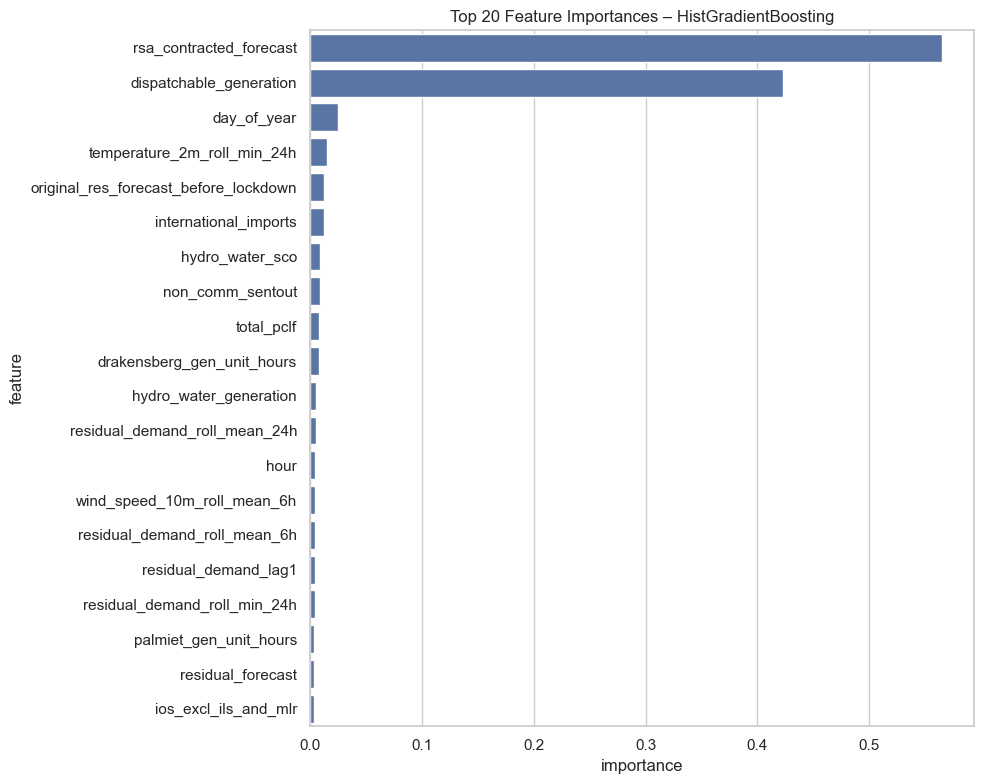

['capstone_outputs\\final_model.pkl']

In [7]:
print_section("PHASE 3 – MODEL TRAINING")

# ---- Helper: find best threshold ----
def find_best_f1_threshold(y_true, probs):
    prec, rec, thresh = precision_recall_curve(y_true, probs)
    f1 = 2 * prec * rec / (prec + rec + np.finfo(float).eps)
    idx = np.argmax(f1)
    if idx < len(thresh):
        return float(thresh[idx])
    return 0.5

# ---- Multi-class models ----
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

multiclass_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,          # reduced from 300 to save memory
        learning_rate=0.08,
        max_depth=4,               # reduced from 6
        subsample=0.5,             # reduced from 0.8
        colsample_bytree=0.5,      # reduced from 0.8
        random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False
    )
}

multi_results = {}
for name, model in multiclass_models.items():
    try:
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="weighted")
        multi_results[name] = {"accuracy": acc, "f1_weighted": f1}
        print(f"{name:25} Acc: {acc:.4f}  F1(w): {f1:.4f}")
    except Exception as e:
        print(f"{name:25} FAILED – {str(e)}")
        # Optionally remove from dict
        del multiclass_models[name]

if not multi_results:
    raise RuntimeError("No multi-class models trained successfully!")

best_multi = max(multi_results, key=lambda k: multi_results[k]["f1_weighted"])
print(f"Best multiclass: {best_multi}")

# ---- Binary model (deployment) ----
y_train_bin = (y_train > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)
bin_weights = compute_sample_weight(class_weight="balanced", y=y_train_bin)

binary_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.06,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)
binary_model.fit(X_train_scaled, y_train_bin, sample_weight=bin_weights)
probs = binary_model.predict_proba(X_test_scaled)[:, 1]
threshold = find_best_f1_threshold(y_test_bin, probs)

preds_bin = (probs >= threshold).astype(int)
bin_acc = accuracy_score(y_test_bin, preds_bin)
bin_f1 = f1_score(y_test_bin, preds_bin, average="weighted")
bin_auc = roc_auc_score(y_test_bin, probs)

print(f"Binary model – Acc: {bin_acc:.4f}  F1(w): {bin_f1:.4f}  ROC AUC: {bin_auc:.4f}  Threshold: {threshold:.4f}")

# ---- Feature importance (best multiclass model) ----
best_model = multiclass_models[best_multi]

# Use built-in importance (HistGradientBoosting has it)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    print("Using built-in feature_importances_")
else:
    from sklearn.inspection import permutation_importance
    print("Computing permutation importance...")
    perm_imp = permutation_importance(
        best_model, X_test_scaled, y_test,
        n_repeats=5, random_state=42, n_jobs=1
    )
    importances = perm_imp.importances_mean

if importances is not None:
    importances = importances / importances.sum()
    imp_df = pd.DataFrame({"feature": features, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False)
    imp_df.to_csv(OUTPUT_DIR / "feature_importances.csv", index=False)
    with open(OUTPUT_DIR / "feature_importances.json", "w") as f:
        json.dump(imp_df.head(20).to_dict(orient="records"), f, indent=2)

    (OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(20), x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances – {best_multi}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / "feature_importance.png", dpi=160)
    plt.show()
else:
    print("Could not extract feature importance.")

# Save binary model
joblib.dump(binary_model, OUTPUT_DIR / "final_model.pkl")

In [8]:
print(imp_df.head(20))

                                  feature  importance
2                 rsa_contracted_forecast    0.565503
3                 dispatchable_generation    0.423203
54                            day_of_year    0.024641
77            temperature_2m_roll_min_24h    0.014579
0   original_res_forecast_before_lockdown    0.012731
7                   international_imports    0.012320
19                        hydro_water_sco    0.008830
36                       non_comm_sentout    0.008830
32                             total_pclf    0.007803
37             drakensberg_gen_unit_hours    0.007598
12                 hydro_water_generation    0.005339
66          residual_demand_roll_mean_24h    0.004928
49                                   hour    0.004517
81            wind_speed_10m_roll_mean_6h    0.004312
63           residual_demand_roll_mean_6h    0.004107
60                   residual_demand_lag1    0.003901
68           residual_demand_roll_min_24h    0.003901
38                 palmiet_g

### LSTM comparison model
A sequence model is trained on the top 20 features (12-hour lookback window) to test whether a recurrent architecture improves on the tree-based ensemble above. Trees already receive explicit lag and rolling-window features, so they hold a structural advantage here; the LSTM is included for completeness and is only kept if it outperforms the deployment model.

In [9]:
# ---- BINARY LSTM (with robust NaN removal) ----
print("\n" + "="*60)
print("BINARY LSTM (with NaN removal)")
print("="*60)

import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Clean data: remove rows with any NaN in X or y
def clean_data(X, y):
    # Convert to numpy if pandas
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values
    # Find rows without NaN in X and y
    valid_rows = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    return X[valid_rows], y[valid_rows]

X_train_clean, y_train_clean = clean_data(X_train_scaled, y_train)
X_test_clean, y_test_clean = clean_data(X_test_scaled, y_test)

print(f"After cleaning: X_train {X_train_clean.shape}, X_test {X_test_clean.shape}")

# 2. Use top 20 features
imp_df = pd.read_csv(OUTPUT_DIR / "feature_importances.csv")
top_features = imp_df.head(20)["feature"].tolist()
feature_indices = [features.index(f) for f in top_features if f in features]
X_train_sub = X_train_clean[:, feature_indices]
X_test_sub  = X_test_clean[:, feature_indices]

# 3. Binary labels
y_train_bin = (y_train_clean > 0).astype(int)
y_test_bin  = (y_test_clean > 0).astype(int)

# 4. Create sequences (lookback = 12)
lookback = 12

def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Use only first 15000 samples to save memory
max_samples = min(15000, len(X_train_sub))
X_train_trim = X_train_sub[:max_samples]
y_train_trim = y_train_bin[:max_samples]

X_train_seq, y_train_seq = create_sequences(X_train_trim, y_train_trim, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_sub, y_test_bin, lookback)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# 5. Build small LSTM
model = Sequential([
    LSTM(16, input_shape=(lookback, X_train_seq.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(8),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 7. Evaluate
y_probs = model.predict(X_test_seq).flatten()
y_pred = (y_probs > 0.5).astype(int)

acc = accuracy_score(y_test_seq, y_pred)
f1 = f1_score(y_test_seq, y_pred)
auc = roc_auc_score(y_test_seq, y_probs)

print(f"\nBinary LSTM – Acc: {acc:.4f}  F1: {f1:.4f}  ROC AUC: {auc:.4f}")

# Save if decent
if acc > 0.85:
    model.save(OUTPUT_DIR / "lstm_binary.keras")
    print("LSTM saved.")
else:
    print("LSTM performance below threshold; not saved.")


BINARY LSTM (with NaN removal)
After cleaning: X_train (30671, 97), X_test (6959, 97)
Train sequences: (14988, 12, 20)
Test sequences: (6947, 12, 20)
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9510 - loss: 0.2449 - val_accuracy: 0.9199 - val_loss: 0.1772
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9787 - loss: 0.0821 - val_accuracy: 0.9216 - val_loss: 0.1652
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9839 - loss: 0.0576 - val_accuracy: 0.9119 - val_loss: 0.1739
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.0419 - val_accuracy: 0.9239 - val_loss: 0.1698
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9909 - loss: 0.0350 - val_accuracy: 0.9036 - val_loss: 0.1804
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Binary LSTM – Acc: 0.5690  F1: 0.3814  ROC AUC: 0.5925
LSTM performance below threshold; not saved.


### Visual diagnostics
Confusion matrix and precision-recall curve for the binary deployment model.


PHASE 3 – VISUALISATIONS


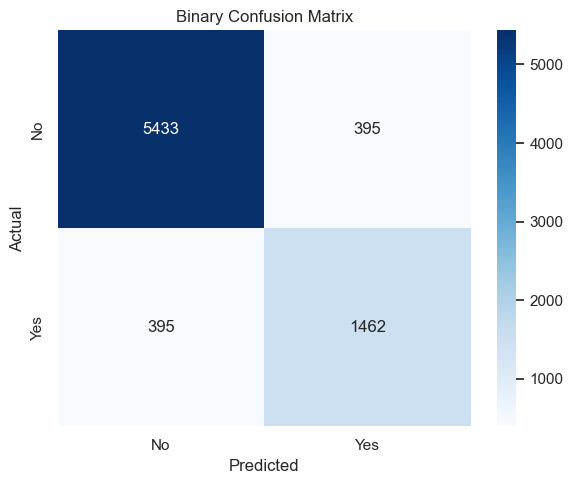

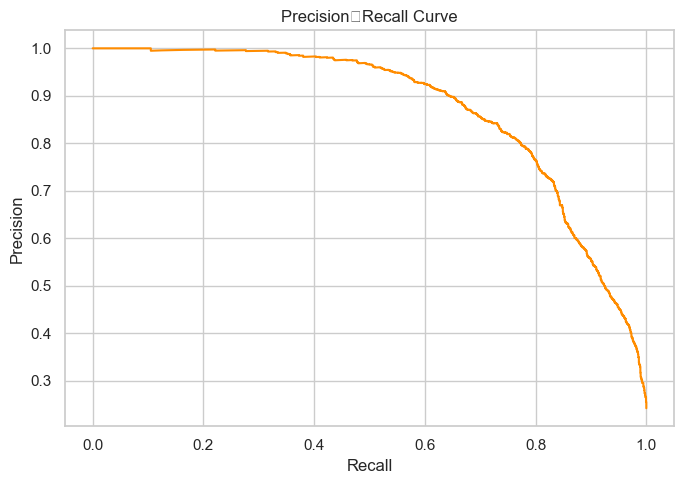

In [10]:
print_section("PHASE 3 – VISUALISATIONS")

# ---- Ensure predictions align with test data ----
y_test_bin_orig = (y_test > 0).astype(int)
probs = binary_model.predict_proba(X_test_scaled)[:, 1]
threshold = find_best_f1_threshold(y_test_bin_orig, probs)
preds_bin = (probs >= threshold).astype(int)
y_test_bin = y_test_bin_orig

# Confusion matrix
cm = confusion_matrix(y_test_bin, preds_bin)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "binary_confusion_matrix.png", dpi=160)
plt.show()

# Precision‑Recall curve
prec, rec, _ = precision_recall_curve(y_test_bin, probs)
plt.figure(figsize=(7,5))
plt.plot(rec, prec, color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision‑Recall Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "precision_recall_curve.png", dpi=160)
plt.show()

## Phase 4 — Persisting Outputs
Saves the trained model, decision threshold, and metrics, and writes the historical/prediction tables to a SQLite database for downstream use (API, reporting, or a dashboard).

In [11]:
print_section("PHASE 4 – SAVING OUTPUTS")
joblib.dump(binary_model, OUTPUT_DIR / "final_model.pkl")
with open(OUTPUT_DIR / "threshold.json", "w") as f:
    json.dump({"threshold": threshold}, f, indent=2)

metrics = {
    "binary": {"accuracy": bin_acc, "f1_weighted": bin_f1, "roc_auc": bin_auc, "threshold": threshold},
    "multiclass": multi_results,
    "best_multiclass": best_multi
}
with open(OUTPUT_DIR / "model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# SQLite database
conn = sqlite3.connect(OUTPUT_DIR / "load_shedding.db")
conn.execute("DROP TABLE IF EXISTS historical_data")
conn.execute("DROP TABLE IF EXISTS predictions")

# Historical data (test set)
hist_cols = ["datetime", "residual_demand", "temperature_2m", "wind_speed_10m",
             "shortwave_radiation", "cloud_cover", "surface_pressure", "dew_point_2m",
             "total_re", "thermal_generation", "nuclear_generation", "stage"]
hist_cols = [c for c in hist_cols if c in test_df.columns]
hist_df = test_df[hist_cols].copy()
hist_df["datetime"] = hist_df["datetime"].astype(str)
hist_df.to_sql("historical_data", conn, if_exists="replace", index=False)

# Predictions
pred_df = pd.DataFrame({
    "datetime": test_df["datetime"].astype(str),
    "probability": probs,
    "predicted_binary": preds_bin,
})
pred_df["risk_level"] = pd.cut(probs, bins=[-np.inf, 0.3, 0.7, np.inf], labels=["Low", "Medium", "High"]).astype(str)
pred_df.to_sql("predictions", conn, if_exists="replace", index=False)
conn.commit()
conn.close()
print("Database saved.")


PHASE 4 – SAVING OUTPUTS
Database saved.


## Phase 5 — Real-World Scenario Demonstration
Rather than hand-built inputs, the low/moderate/high risk examples below are **real rows pulled from the held-out test set** — chosen by predicted probability (lowest/highest) and by actual stage label (moderate). Risk-level bands are anchored to the model's own F1-optimal decision threshold rather than an arbitrary fixed cutoff, so the qualitative label always agrees with the binary prediction.

In [12]:
# ---- PREDICT FUNCTION (risk bands anchored to the model's actual decision threshold) ----
def predict(payload):
    input_df = pd.DataFrame([[payload.get(f, 0) for f in features]], columns=features)
    scaled = scaler.transform(input_df)
    prob = binary_model.predict_proba(scaled)[0, 1]
    pred = int(prob >= threshold)
    # "Low" now always means "not flagged by the model" (prob below the
    # F1-optimal decision threshold), instead of an arbitrary fixed cutoff
    # that had almost every real probability falling under it.
    if prob < threshold:
        risk = "Low"
    elif prob < 0.5:
        risk = "Medium"
    else:
        risk = "High"
    return prob, pred, risk


# ---- FIND REAL LOW / MODERATE / HIGH RISK EXAMPLES FROM THE TEST SET ----
# This uses the variables from the retraining cell above.

# Recompute probabilities on the test set
test_probs = binary_model.predict_proba(X_test_scaled)[:, 1]

# ---- HIGH RISK: highest predicted probability ----
high_idx = np.argmax(test_probs)
high_risk_real = {}
for i, f in enumerate(features):
    high_risk_real[f] = X_test.iloc[high_idx][f]

# ---- LOW RISK: lowest predicted probability ----
low_idx = np.argmin(test_probs)
low_risk_real = {}
for i, f in enumerate(features):
    low_risk_real[f] = X_test.iloc[low_idx][f]

# ---- MODERATE RISK: a real row where the actual stage is 1 or 2 ----
moderate_mask = (y_test.values >= 1) & (y_test.values <= 2)
moderate_candidates = np.where(moderate_mask)[0]
if len(moderate_candidates) > 0:
    mod_idx = moderate_candidates[0]
else:
    # fallback: closest-to-median probability if no stage 1/2 rows exist in the test set
    mod_idx = np.argsort(np.abs(test_probs - np.median(test_probs)))[0]
moderate_risk_real = {}
for i, f in enumerate(features):
    moderate_risk_real[f] = X_test.iloc[mod_idx][f]

print("Selected real test-set rows for each scenario:")
print(f"  Low risk      -> row {low_idx},  predicted prob {test_probs[low_idx]:.4f},  actual stage {y_test.iloc[low_idx]}")
print(f"  Moderate risk -> row {mod_idx},  predicted prob {test_probs[mod_idx]:.4f},  actual stage {y_test.iloc[mod_idx]}")
print(f"  High risk     -> row {high_idx}, predicted prob {test_probs[high_idx]:.4f},  actual stage {y_test.iloc[high_idx]}")
print()

# ---- RUN PREDICTIONS ----
low_prob, low_pred, low_risk_label = predict(low_risk_real)
mod_prob, mod_pred, mod_risk_label = predict(moderate_risk_real)
high_prob, high_pred, high_risk_label = predict(high_risk_real)

# ---- DISPLAY RESULTS ----
print("="*60)
print("TEST SCENARIO RESULTS (all rows are real, held-out test examples)")
print("="*60)
print(f"{'Scenario':<12} | {'Probability':<12} | {'Prediction':<16} | {'Risk Level'}")
print("-"*60)
print(f"{'Low':<12} | {low_prob*100:>6.2f}%     | {'Load-shedding' if low_pred else 'No load-shedding':<16} | {low_risk_label}")
print(f"{'Moderate':<12} | {mod_prob*100:>6.2f}%     | {'Load-shedding' if mod_pred else 'No load-shedding':<16} | {mod_risk_label}")
print(f"{'High':<12} | {high_prob*100:>6.2f}%     | {'Load-shedding' if high_pred else 'No load-shedding':<16} | {high_risk_label}")
print("="*60)
print(f"Decision threshold: {threshold:.4f}")

Selected real test-set rows for each scenario:
  Low risk      -> row 1270,  predicted prob 0.0000,  actual stage 0
  Moderate risk -> row 123,  predicted prob 0.2851,  actual stage 2
  High risk     -> row 6458, predicted prob 0.9843,  actual stage 5

TEST SCENARIO RESULTS (all rows are real, held-out test examples)
Scenario     | Probability  | Prediction       | Risk Level
------------------------------------------------------------
Low          |   0.00%     | No load-shedding | Low
Moderate     |  28.51%     | Load-shedding    | Medium
High         |  98.43%     | Load-shedding    | High
Decision threshold: 0.0296
